# Proyek Prediksi Harga Komoditas Pertanian
## Alur Kerja Proyek

## 1. Setup Environment
- Instalasi library yang diperlukan (RAPIDS, TensorFlow, dll)
- Import library yang diperlukan

In [7]:
# Core Libraries
import cudf  # GPU-accelerated dataframe
import cupy as cp  # GPU-accelerated numerical computing
import numpy as np  # Numerical computing
import pandas as pd  # Fallback for CPU operations
import seaborn as sns

# Data Processing
from cuml.preprocessing import MinMaxScaler  # GPU-accelerated scaling
from sklearn.model_selection import train_test_split  # Fallback for data splitting

# Machine Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Evaluation Metrics
from cuml.metrics import regression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Print library versions
print(f"cuDF Version: {cudf.__version__}")
print(f"CuPy Version: {cp.__version__}")
print(f"TensorFlow Version: {tf.__version__}")

# GPU Check
from numba import cuda

if cuda.is_available():
    print("\nGPU Detected:")
    device = cuda.get_current_device()
    print(f"Device Name: {device.name}") 
else:
    print("Warning: No GPU detected - Falling back to CPU mode")



cuDF Version: 24.10.01
CuPy Version: 13.3.0
TensorFlow Version: 2.17.0

GPU Detected:
Device Name: b'NVIDIA GeForce RTX 4050 Laptop GPU'


## 2. Data Understanding
- Load dataset (Harga.csv dan Triwulan.csv)
- Lakukan eksplorasi data (lihat beberapa baris pertama, cek missing values)

In [8]:
def load_datasets():
    """
    Memuat dataset Harga.csv dan Triwulan.csv dengan cudf.
    Mengembalikan tuple (harga_df, triwulan_df).
    """
    try:
        # Load Harga.csv (data harian)
        harga_df = cudf.read_csv('Harga.csv', parse_dates=['Tanggal'], skipinitialspace=True)
        
        # Load Triwulan.csv (data produksi)
        triwulan_df = cudf.read_csv('Triwulan.csv', skipinitialspace=True)
        
        # Validasi keberadaan kolom penting
        required_harga_cols = {'Komoditi', 'Tanggal', 'Harga Petani', 'Harga Pengecer'}
        required_triwulan_cols = {'Komoditas', 'tahun', 'triwulan', 'Luas Panen', 'Produktivitas', 'Produksi'}
        
        assert required_harga_cols.issubset(harga_df.columns), "Kolom tidak valid di Harga.csv"
        assert required_triwulan_cols.issubset(triwulan_df.columns), "Kolom tidak valid di Triwulan.csv"
        
        print("✔ Dataset berhasil dimuat")
        print(f"- Harga.csv: {len(harga_df)} baris")
        print(f"- Triwulan.csv: {len(triwulan_df)} baris")
        
        return harga_df, triwulan_df
    
    except FileNotFoundError as e:
        print(f"❌ File tidak ditemukan: {e}")
        return None, None
    except Exception as e:
        print(f"❌ Error saat memuat dataset: {e}")
        return None, None

# Contoh penggunaan
harga_df, triwulan_df = load_datasets()

if harga_df is not None:
    print("\n5 baris pertama Harga.csv:")
    print(harga_df.head())

if triwulan_df is not None:
    print("\n5 baris pertama Triwulan.csv:")
    print(triwulan_df.head())


✔ Dataset berhasil dimuat
- Harga.csv: 4289 baris
- Triwulan.csv: 30 baris

5 baris pertama Harga.csv:
              Komoditi    Tanggal  Harga Petani  Harga Pengecer
0  Jagung Pipil Kering 2022-01-03          4800            5000
1  Jagung Pipil Kering 2022-01-04          4800            5000
2  Jagung Pipil Kering 2022-01-05          4800            5000
3  Jagung Pipil Kering 2022-01-06          4800            5000
4  Jagung Pipil Kering 2022-01-07          4800            5000

5 baris pertama Triwulan.csv:
    Komoditas  tahun  triwulan  Luas Panen  Produktivitas   Produksi
0  Padi sawah   2022         1  35685.6200      56.593625  201957.86
1  Padi sawah   2022         2  12599.0000      54.279752   68387.06
2  Padi sawah   2022         3   6888.7897      55.240632   38054.11
3  Padi sawah   2023         1  26790.3606      55.977470  149965.66
4  Padi sawah   2023         2  21687.8044      58.797478  127518.82


In [9]:
# Eksplorasi Data Harga
def explore_harga_data(harga_df):
    """
    Melakukan eksplorasi data pada DataFrame harga_df.
    """
    # 1. Cek kolom dan tipe data
    print("1. Kolom dan Tipe Data:")
    print(harga_df.dtypes)
    print("\n")

    # 2. Cek data duplikat
    duplicate_count = harga_df.duplicated().sum()
    print(f"2. Jumlah Data Duplikat: {duplicate_count}")
    print("\n")

    # 3. Cek missing values
    missing_values = harga_df.isnull().sum()
    print("3. Missing Values:")
    print(missing_values[missing_values > 0])  # Hanya tampilkan kolom dengan missing values
    print("\n")

    # 4. Ringkasan Statistik untuk Data Numerik
    print("4. Ringkasan Statistik (Data Numerik):")
    print(harga_df.describe())
    print("\n")

    # 5. Ringkasan Statistik untuk Data Kategorikal
    print("5. Ringkasan Statistik (Data Kategorikal):")
    categorical_summary = harga_df.describe(include=['object', 'category'])
    print(categorical_summary)
    print("\n")

# Contoh penggunaan
if harga_df is not None:
    explore_harga_data(harga_df)


1. Kolom dan Tipe Data:
Komoditi                  object
Tanggal           datetime64[ns]
Harga Petani               int64
Harga Pengecer             int64
dtype: object


2. Jumlah Data Duplikat: 0


3. Missing Values:
Tanggal              1
Harga Petani      1410
Harga Pengecer    1409
dtype: int64


4. Ringkasan Statistik (Data Numerik):
                             Tanggal  Harga Petani  Harga Pengecer
count                           4288   2879.000000     2880.000000
mean   2023-06-21 04:27:18.805970176   9958.318861    11177.604167
min              2022-01-01 00:00:00   3300.000000     3600.000000
25%    2022-09-26 00:00:00.000000000   8200.000000     9000.000000
50%    2023-06-21 00:00:00.000000000  10500.000000    11500.000000
75%    2024-03-15 00:00:00.000000000  13000.000000    15000.000000
max              2024-12-31 00:00:00  15500.000000    17500.000000
std                             <NA>   3566.228031     4337.264336


5. Ringkasan Statistik (Data Kategorikal):
         

In [37]:
harga_df = harga_df.rename(columns={
    ' Harga Petani ': 'Harga Petani',
    ' Harga Pengecer ': 'Harga Pengecer'
})

In [ ]:
df=harga_df

                 Komoditi    Tanggal  Harga Petani  Harga Pengecer  Bulan
0     Jagung Pipil Kering 2022-01-03        4800.0          5000.0      1
1     Jagung Pipil Kering 2022-01-04        4800.0          5000.0      1
2     Jagung Pipil Kering 2022-01-05        4800.0          5000.0      1
3     Jagung Pipil Kering 2022-01-06        4800.0          5000.0      1
4     Jagung Pipil Kering 2022-01-07        4800.0          5000.0      1
...                   ...        ...           ...             ...    ...
4284         Kacang Hijau 2024-12-27       13000.0         15000.0     12
4285         Kacang Hijau 2024-12-28       13000.0         15000.0     12
4286         Kacang Hijau 2024-12-29       13000.0         15000.0     12
4287         Kacang Hijau 2024-12-30       13000.0         15000.0     12
4288         Kacang Hijau 2024-12-31       13000.0         15000.0     12

[4288 rows x 5 columns]


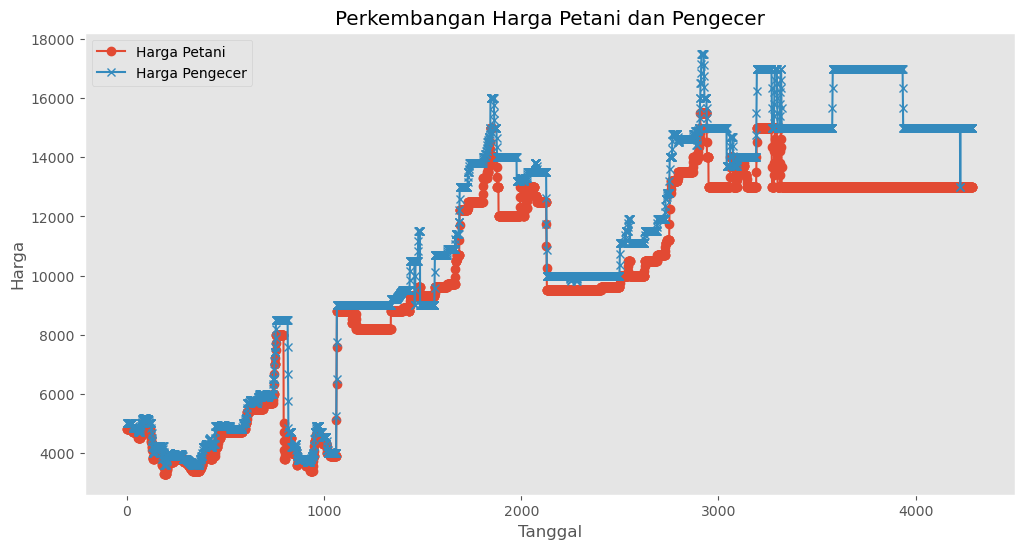

In [ ]:

# Membuat DataFrame
df = data

# Melakukan interpolasi linear
df['Harga Petani'] = df['Harga Petani'].interpolate(method='linear')
df['Harga Pengecer'] = df['Harga Pengecer'].interpolate(method='linear')

# Menampilkan DataFrame setelah interpolasi
print(df)

# Plot hasil
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Harga Petani'], label='Harga Petani', marker='o')
plt.plot(df.index, df['Harga Pengecer'], label='Harga Pengecer', marker='x')
plt.title('Perkembangan Harga Petani dan Pengecer')
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.legend()
plt.grid()
plt.show()


In [44]:
print(harga_df.isnull().sum())

Komoditi          0
Tanggal           0
Harga Petani      0
Harga Pengecer    0
Bulan             0
dtype: int64


In [43]:
df.dropna(inplace=True)


🧹 Membersihkan data...

🔍 Inspeksi Dasar:
Dimensi Data: (4289, 4)

Tipe Data:
 Komoditi                  object
Tanggal           datetime64[ns]
Harga Petani             float64
Harga Pengecer           float64
dtype: object

5 Sample Data:
               Komoditi    Tanggal  Harga Petani  Harga Pengecer
0  Jagung Pipil Kering 2022-01-03        4800.0          5000.0
1  Jagung Pipil Kering 2022-01-04        4800.0          5000.0
2  Jagung Pipil Kering 2022-01-05        4800.0          5000.0
3  Jagung Pipil Kering 2022-01-06        4800.0          5000.0
4  Jagung Pipil Kering 2022-01-07        4800.0          5000.0

❓ Missing Values:
Tanggal              1
Harga Petani      1410
Harga Pengecer    1409
dtype: int64

♻ Data Duplikat: 0

📊 Statistical Summary (Numerical):
                             Tanggal  Harga Petani  Harga Pengecer
count                           4288   2879.000000     2880.000000
mean   2023-06-21 04:27:18.805970176   9958.318861    11177.604167
min            

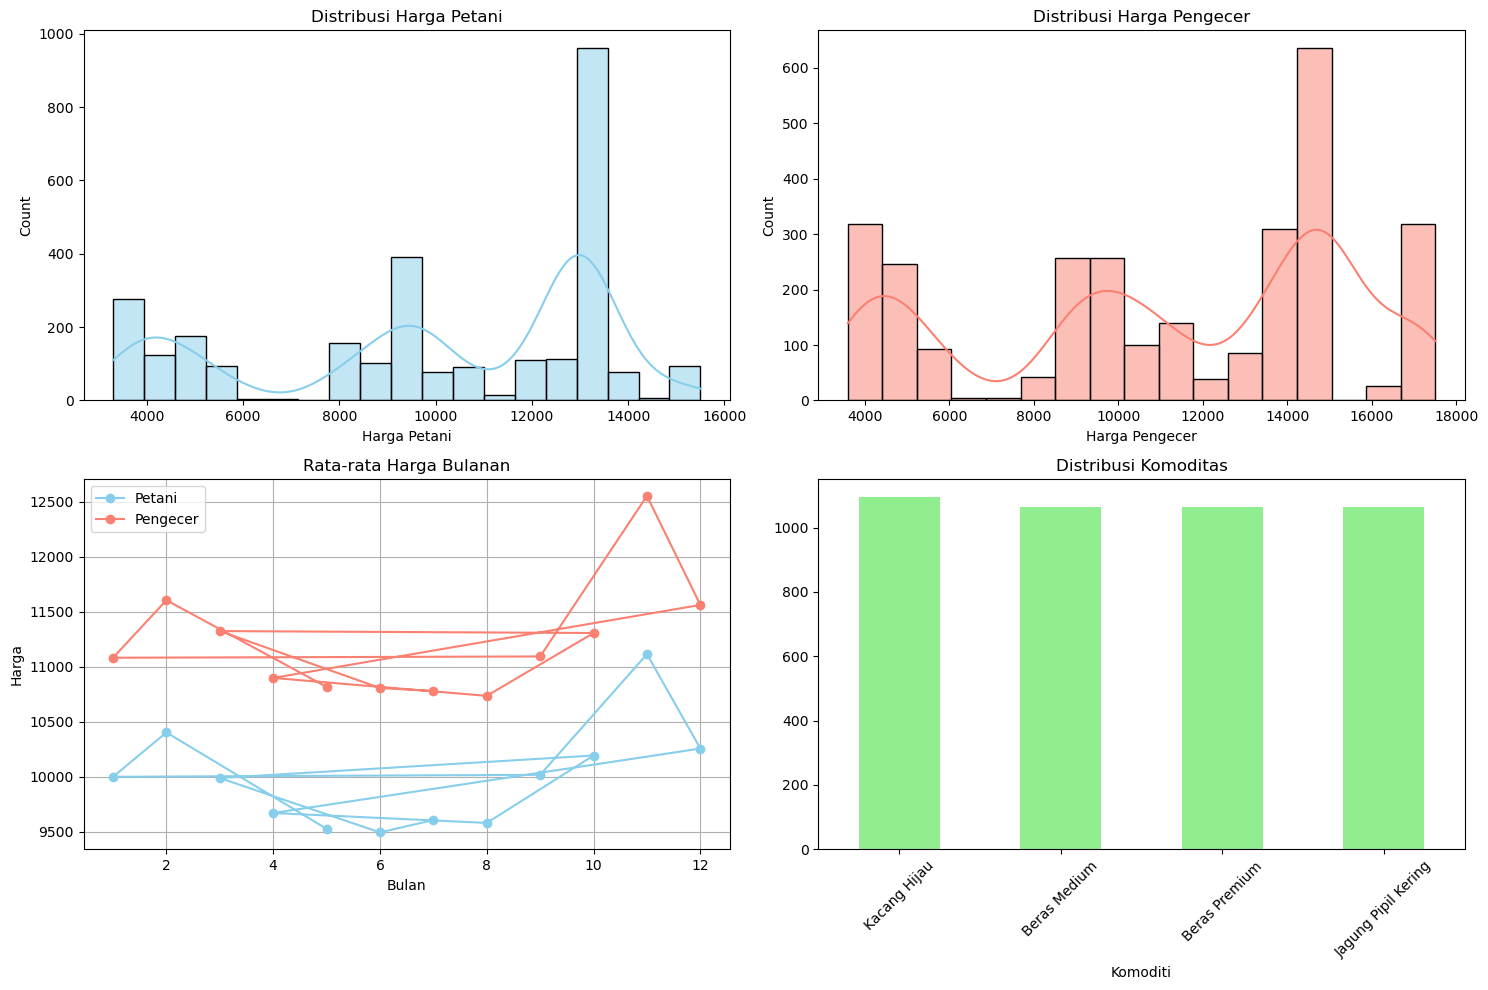

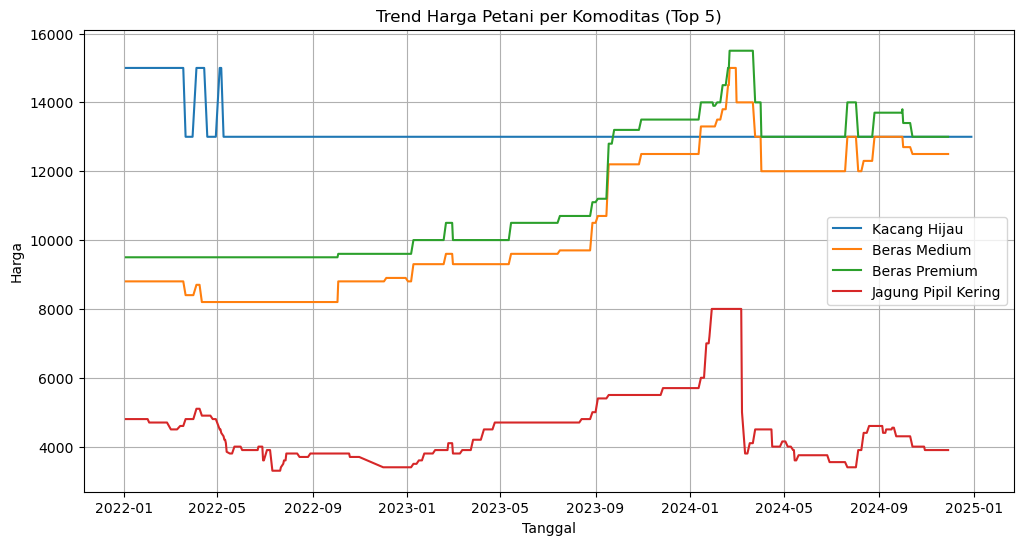

In [10]:
import cudf
import matplotlib.pyplot as plt
import seaborn as sns

# Fungsi untuk membersihkan kolom harga
def clean_price_column(series):
    # Pastikan kolom diubah menjadi string
    series = series.astype(str)
    return (
        series.str.replace('Rp', '', regex=False)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
        .str.strip()
        .astype(float)
    )

# 2. Data Cleaning
print("\n🧹 Membersihkan data...")
for col in ['Harga Petani', 'Harga Pengecer']:
    harga_df[col] = clean_price_column(harga_df[col])

# 3. Basic Inspection
print("\n🔍 Inspeksi Dasar:")
print("Dimensi Data:", harga_df.shape)
print("\nTipe Data:\n", harga_df.dtypes)
print("\n5 Sample Data:\n", harga_df.head())

# 4. Check Missing Values
print("\n❓ Missing Values:")
missing_values = harga_df.isnull().sum()
print(missing_values[missing_values > 0])

# 5. Check Duplicates
print("\n♻ Data Duplikat:", harga_df.duplicated().sum())

# 6. Statistical Summary
print("\n📊 Statistical Summary (Numerical):")
print(harga_df.describe())

# 7. Categorical Analysis
print("\n📊 Statistical Summary (Categorical):")
print(harga_df['Komoditi'].describe())

# ========= VISUALIZATION =========
plt.figure(figsize=(15, 10))

# 8. Price Distribution
plt.subplot(2, 2, 1)
sns.histplot(harga_df['Harga Petani'].to_pandas(), kde=True, color='skyblue')
plt.title('Distribusi Harga Petani')

plt.subplot(2, 2, 2)
sns.histplot(harga_df['Harga Pengecer'].to_pandas(), kde=True, color='salmon')
plt.title('Distribusi Harga Pengecer')

# 9. Price Trends
harga_df['Bulan'] = harga_df['Tanggal'].dt.month
monthly_avg = harga_df.groupby('Bulan')[['Harga Petani', 'Harga Pengecer']].mean()

plt.subplot(2, 2, 3)
monthly_avg['Harga Petani'].to_pandas().plot(marker='o', color='skyblue')
monthly_avg['Harga Pengecer'].to_pandas().plot(marker='o', color='salmon')
plt.title('Rata-rata Harga Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Harga')
plt.legend(['Petani', 'Pengecer'])
plt.grid(True)

# 10. Commodity Analysis
plt.subplot(2, 2, 4)
harga_df['Komoditi'].value_counts().to_pandas().plot(kind='bar', color='lightgreen')
plt.title('Distribusi Komoditas')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 11. Price Comparison by Commodity
plt.figure(figsize=(12, 6))
top_commodities = harga_df['Komoditi'].value_counts().head(5).index.to_pandas()

for commodity in top_commodities:
    subset = harga_df[harga_df['Komoditi'] == commodity]
    sns.lineplot(
        x=subset['Tanggal'].to_pandas(),
        y=subset['Harga Petani'].to_pandas(),
        label=commodity
    )

plt.title('Trend Harga Petani per Komoditas (Top 5)')
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.legend()
plt.grid(True)
plt.show()


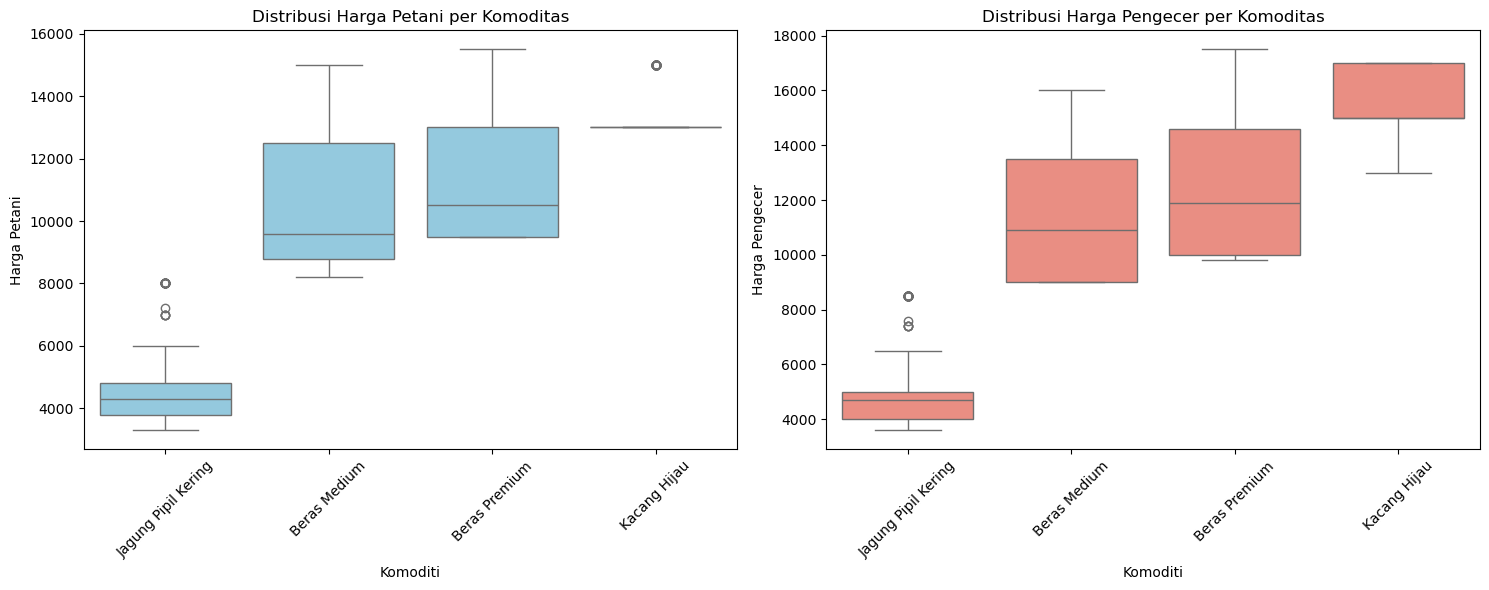

In [11]:
plt.figure(figsize=(15, 6))

# Boxplot Harga Petani per Komoditas
plt.subplot(1, 2, 1)
sns.boxplot(data=harga_df.to_pandas(), 
           x='Komoditi', y='Harga Petani',
           color='skyblue')
plt.title('Distribusi Harga Petani per Komoditas')
plt.xticks(rotation=45)

# Boxplot Harga Pengecer per Komoditas
plt.subplot(1, 2, 2)
sns.boxplot(data=harga_df.to_pandas(), 
           x='Komoditi', y='Harga Pengecer',
           color='salmon')
plt.title('Distribusi Harga Pengecer per Komoditas')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [12]:
harga_df['Harga Petani'].max()

15500.0

In [13]:
harga_df.head()

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Bulan
0,Jagung Pipil Kering,2022-01-03,4800.0,5000.0,1
1,Jagung Pipil Kering,2022-01-04,4800.0,5000.0,1
2,Jagung Pipil Kering,2022-01-05,4800.0,5000.0,1
3,Jagung Pipil Kering,2022-01-06,4800.0,5000.0,1
4,Jagung Pipil Kering,2022-01-07,4800.0,5000.0,1


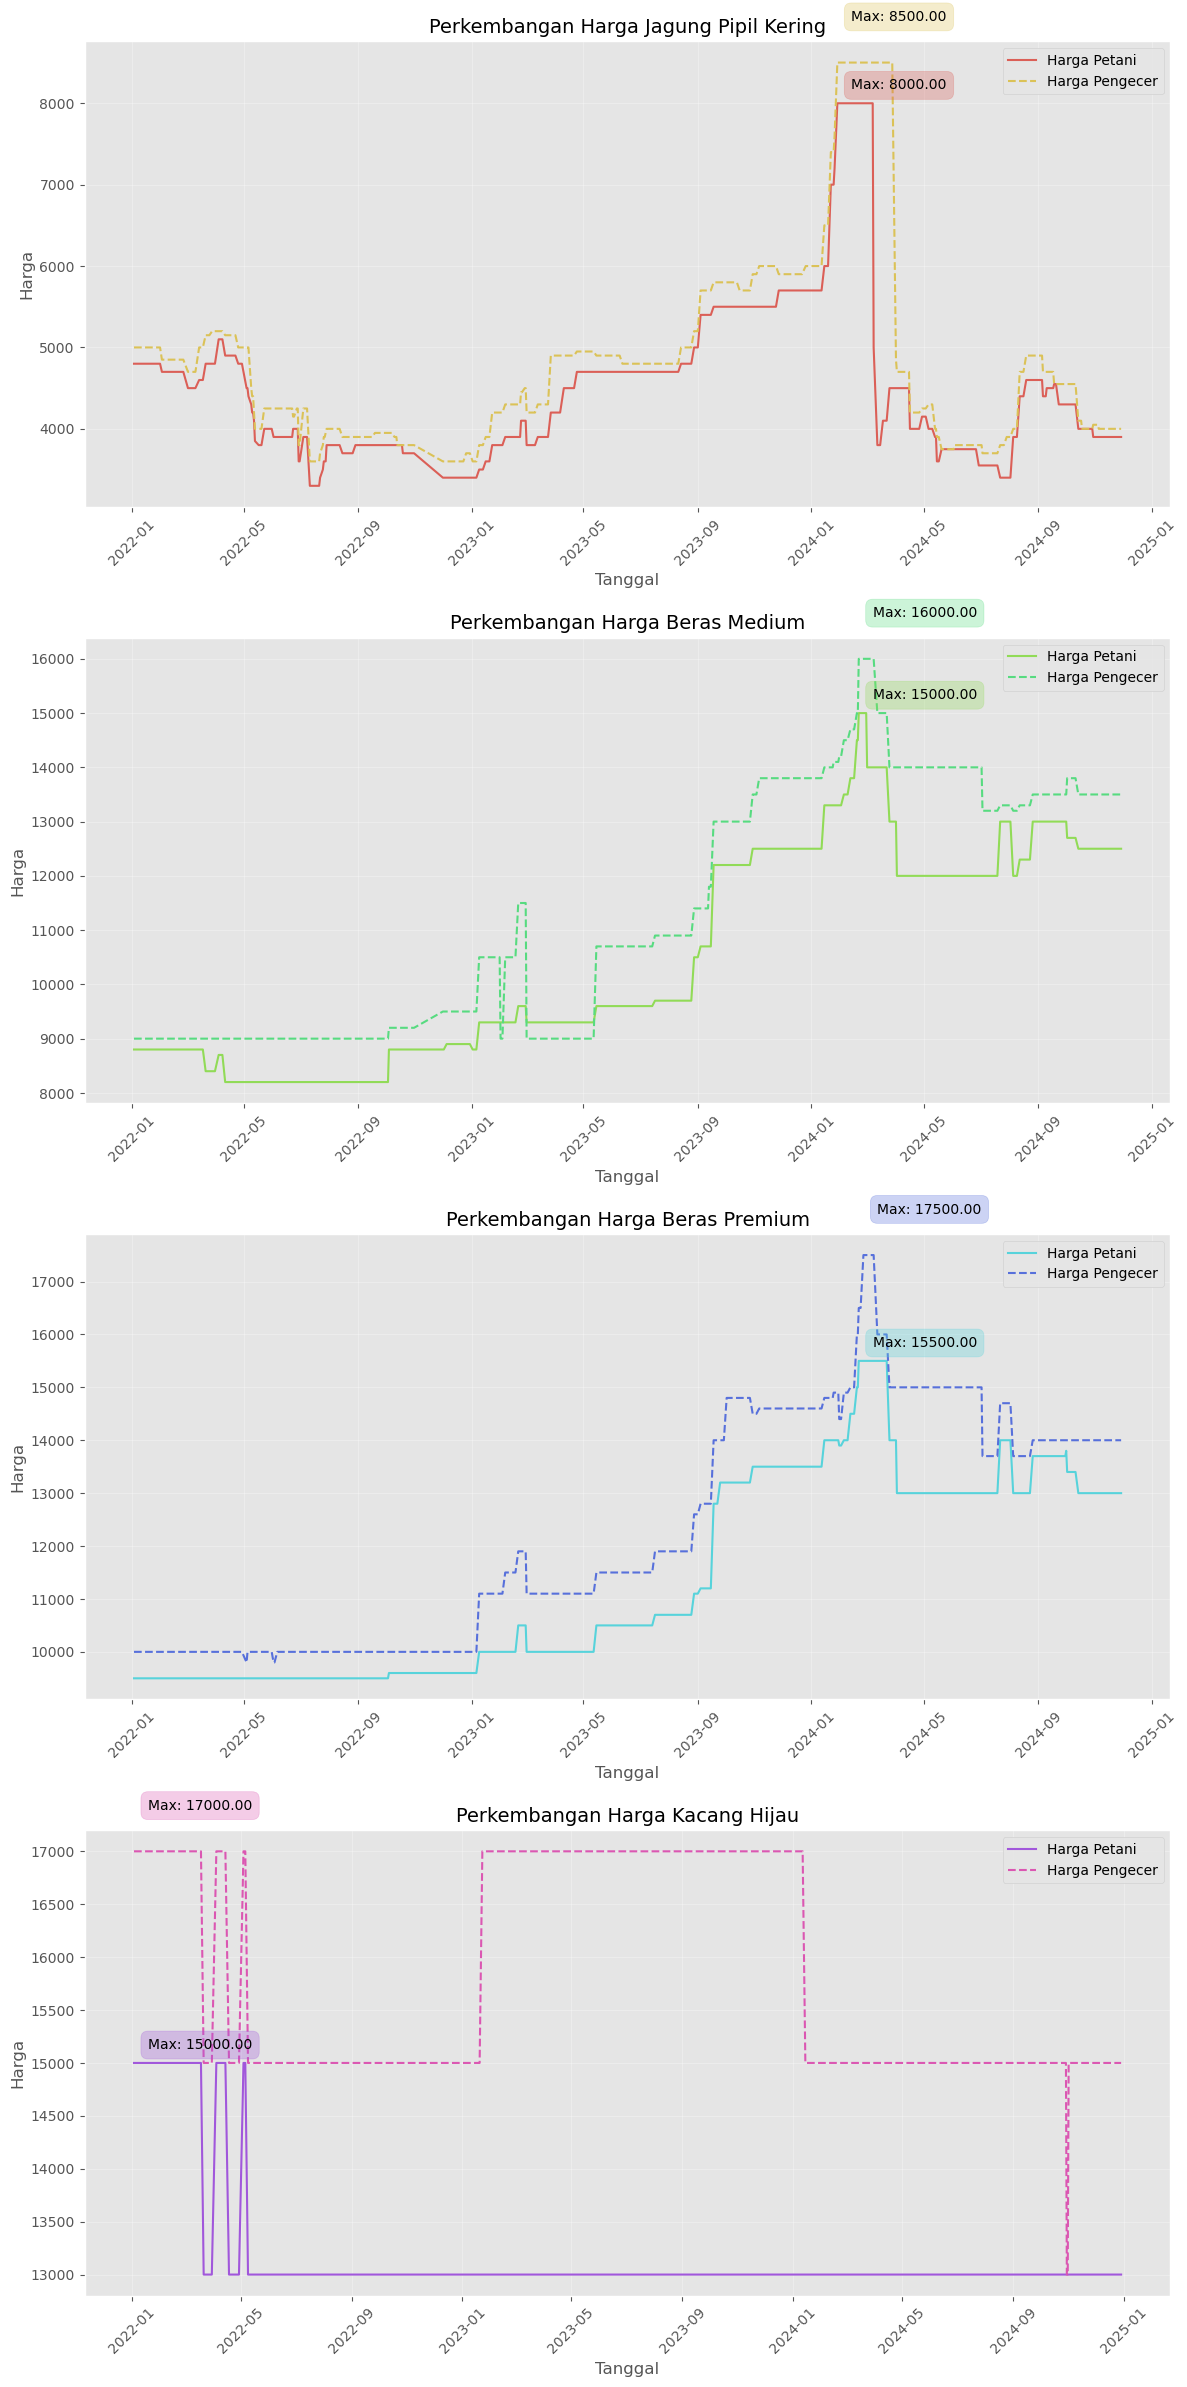

In [14]:
# Custom style
plt.style.use('ggplot')
colors = sns.color_palette("hls", 8)  # 8 warna berbeda untuk komoditas

# Daftar komoditas unik
komoditas_list = harga_df['Komoditi'].unique().to_pandas()

# Buat figure dengan subplot untuk setiap komoditas
fig, axes = plt.subplots(len(komoditas_list), 1, figsize=(12, 6*len(komoditas_list)))

# Plot per komoditas
for idx, komod in enumerate(komoditas_list):
    ax = axes[idx] if len(komoditas_list) > 1 else axes
    subset = harga_df[harga_df['Komoditi'] == komod]
    
    # Line plot
    sns.lineplot(data=subset.to_pandas(), 
                 x='Tanggal', y='Harga Petani', 
                 label='Harga Petani', color=colors[idx*2], ax=ax)
    sns.lineplot(data=subset.to_pandas(), 
                 x='Tanggal', y='Harga Pengecer', 
                 label='Harga Pengecer', color=colors[idx*2+1], linestyle='--', ax=ax)
    
    # Annotasi titik maksimum untuk Harga Petani
    max_petani = subset['Harga Petani'].max()
    max_date_petani = subset[subset['Harga Petani'] == max_petani]['Tanggal'].iloc[0]
    
    ax.annotate(f'Max: {max_petani:.2f}', 
                 xy=(max_date_petani, max_petani),
                 xytext=(10, 10), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.5', alpha=0.3, color=colors[idx*2]))
    
    # Annotasi titik maksimum untuk Harga Pengecer
    max_pengecer = subset['Harga Pengecer'].max()
    max_date_pengecer = subset[subset['Harga Pengecer'] == max_pengecer]['Tanggal'].iloc[0]
    
    ax.annotate(f'Max: {max_pengecer:.2f}', 
                 xy=(max_date_pengecer, max_pengecer),
                 xytext=(10, 30), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.5', alpha=0.3, color=colors[idx*2+1]))
    
    # Customisasi plot
    ax.set_title(f'Perkembangan Harga {komod}', fontsize=14)
    ax.set_xlabel('Tanggal', fontsize=12)
    ax.set_ylabel('Harga', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Rotasi label tanggal
    for tick in ax.get_xticklabels():
        tick.set_rotation(45)

plt.tight_layout()
plt.show()


Deteksi Outlier dengan Z-Score

In [46]:
from scipy import stats

# Fungsi untuk mendeteksi outlier menggunakan Z-score
def detect_outliers_zscore(data):
    z_scores = stats.zscore(data)
    return np.abs(z_scores) > 3  # Ambil threshold 3 untuk Z-score

# Group by Komoditi dan deteksi outlier
outliers_results_z = []

# Mengonversi ke pandas untuk iterasi
komoditas_list = harga_df['Komoditi'].to_pandas().unique()

for komod in komoditas_list:
    subset = harga_df[harga_df['Komoditi'] == komod]
    
    # Deteksi outlier untuk Harga Petani dan Harga Pengecer
    # Konversi ke pandas untuk menghitung Z-score
    petani_z = detect_outliers_zscore(subset['Harga Petani'].to_pandas())
    pengecer_z = detect_outliers_zscore(subset['Harga Pengecer'].to_pandas())
    
    # Tambahkan kolom outlier ke subset
    subset['Outlier_Petani_Z'] = petani_z
    subset['Outlier_Pengecer_Z'] = pengecer_z
    
    # Simpan hasil
    outliers_results_z.append(subset[subset['Outlier_Petani_Z'] | subset['Outlier_Pengecer_Z']])

# Gabungkan hasil outlier
outliers_df_z = cudf.concat(outliers_results_z)

# Tampilkan hasil
print("Outliers per Komoditi (Z-score):")
print(outliers_df_z[['Tanggal', 'Komoditi', 'Harga Petani', 'Outlier_Petani_Z', 'Harga Pengecer', 'Outlier_Pengecer_Z']])


Outliers per Komoditi (Z-score):
        Tanggal             Komoditi  Harga Petani  Outlier_Petani_Z  \
754  2024-01-27  Jagung Pipil Kering   7466.666667              True   
755  2024-01-28  Jagung Pipil Kering   7733.333333              True   
756  2024-01-29  Jagung Pipil Kering   8000.000000              True   
757  2024-01-30  Jagung Pipil Kering   8000.000000              True   
758  2024-01-31  Jagung Pipil Kering   8000.000000              True   
...         ...                  ...           ...               ...   
3295 2022-04-13         Kacang Hijau  15000.000000              True   
3296 2022-04-14         Kacang Hijau  15000.000000              True   
3316 2022-05-04         Kacang Hijau  15000.000000              True   
3317 2022-05-05         Kacang Hijau  15000.000000              True   
3318 2022-05-06         Kacang Hijau  15000.000000              True   

      Harga Pengecer  Outlier_Pengecer_Z  
754           7900.0               False  
755           82

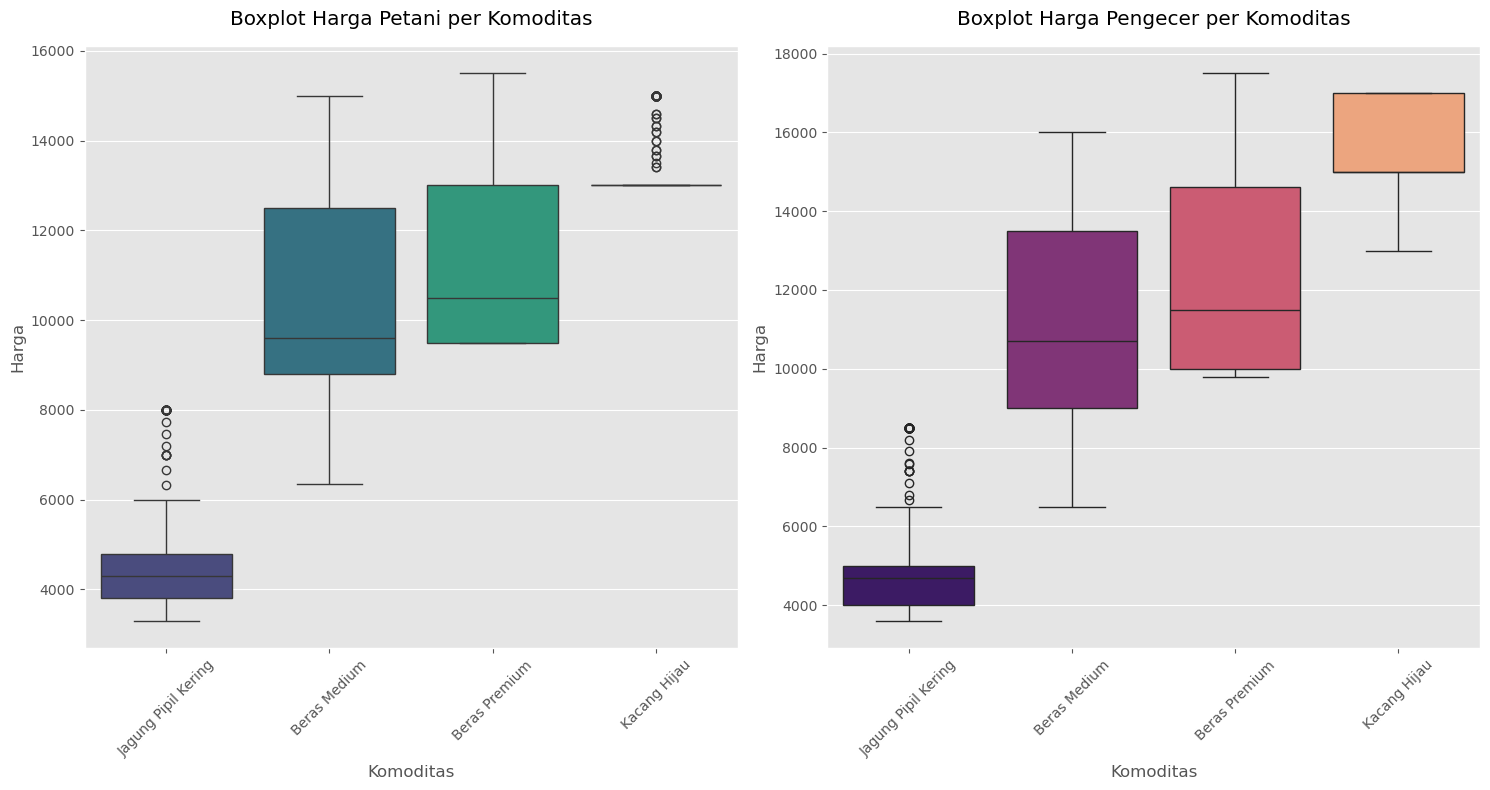

In [47]:

# Konversi ke pandas untuk plotting (karena cuDF tidak memiliki fungsi plotting)
harga_pandas = harga_df.to_pandas()

# Set style
plt.style.use('ggplot')
plt.figure(figsize=(15, 8))

# Boxplot untuk Harga Petani per Komoditas
plt.subplot(1, 2, 1)
sns.boxplot(data=harga_pandas, x='Komoditi', y='Harga Petani', 
            palette='viridis', showfliers=True)
plt.title('Boxplot Harga Petani per Komoditas', pad=15)
plt.xlabel('Komoditas')
plt.ylabel('Harga')
plt.xticks(rotation=45)

# Boxplot untuk Harga Pengecer per Komoditas
plt.subplot(1, 2, 2)
sns.boxplot(data=harga_pandas, x='Komoditi', y='Harga Pengecer', 
            palette='magma', showfliers=True)
plt.title('Boxplot Harga Pengecer per Komoditas', pad=15)
plt.xlabel('Komoditas')
plt.ylabel('Harga')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


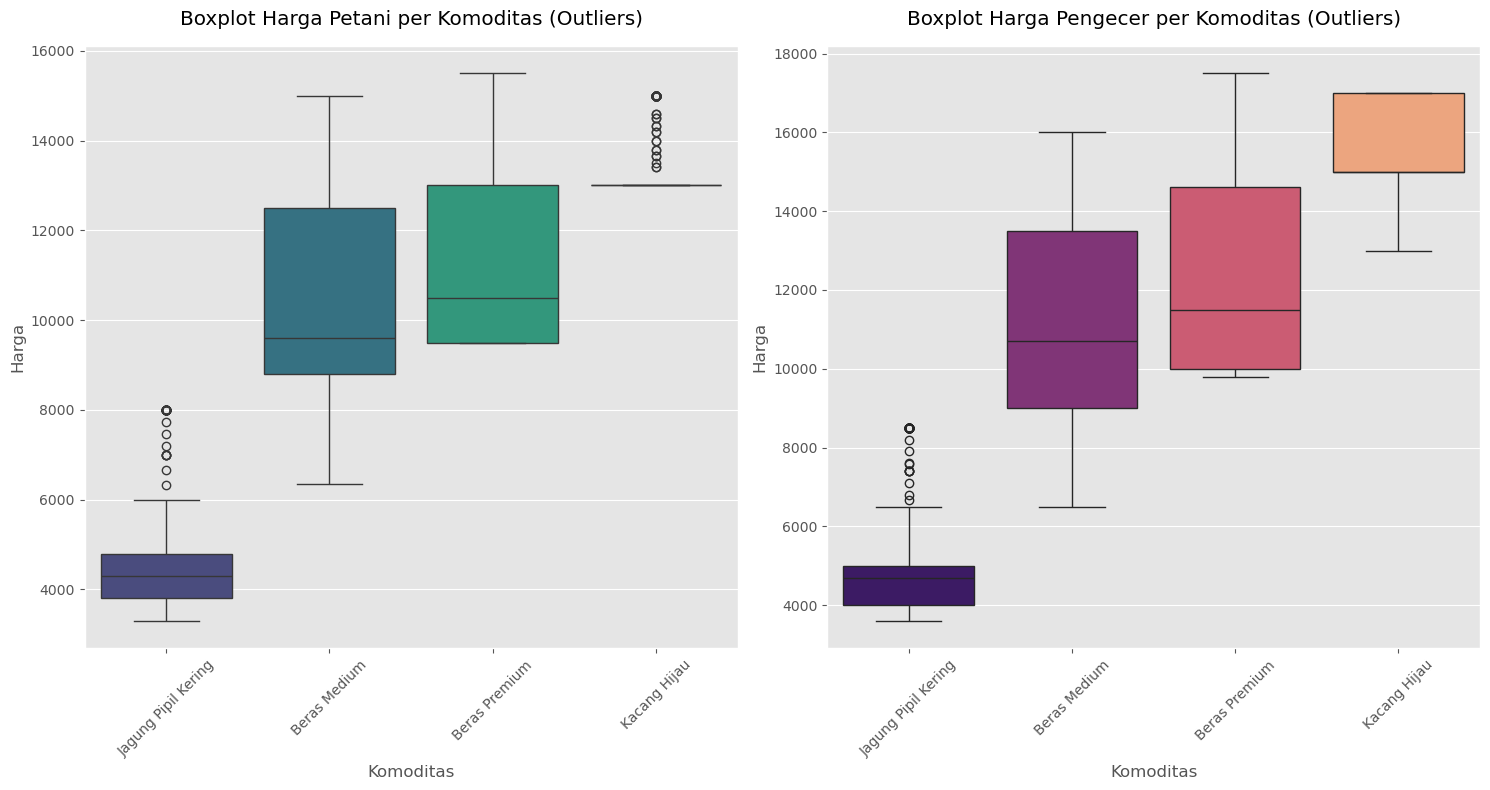

In [48]:

# Konversi ke pandas untuk plotting (karena cuDF tidak memiliki fungsi plotting)
harga_pandas = harga_df.to_pandas()

# Fungsi untuk mendeteksi outlier menggunakan Z-score
def detect_outliers_zscore(data):
    z_scores = stats.zscore(data)
    return np.abs(z_scores) > 3  # Ambil threshold 3 untuk Z-score

# Group by Komoditi dan deteksi outlier
outliers_results_z = []

# Mengonversi ke pandas untuk iterasi
komoditas_list = harga_pandas['Komoditi'].unique()

for komod in komoditas_list:
    subset = harga_pandas[harga_pandas['Komoditi'] == komod]
    
    # Deteksi outlier untuk Harga Petani dan Harga Pengecer
    petani_z = detect_outliers_zscore(subset['Harga Petani'])
    pengecer_z = detect_outliers_zscore(subset['Harga Pengecer'])
    
    # Tambahkan kolom outlier ke subset
    subset['Outlier_Petani_Z'] = petani_z
    subset['Outlier_Pengecer_Z'] = pengecer_z
    
    # Simpan hasil
    outliers_results_z.append(subset)

# Gabungkan hasil outlier
outliers_df_z = pd.concat(outliers_results_z)

# Set style
plt.style.use('ggplot')
plt.figure(figsize=(15, 8))

# Boxplot untuk Harga Petani per Komoditas
plt.subplot(1, 2, 1)
sns.boxplot(data=outliers_df_z, x='Komoditi', y='Harga Petani', 
            palette='viridis', showfliers=True)
plt.title('Boxplot Harga Petani per Komoditas (Outliers)', pad=15)
plt.xlabel('Komoditas')
plt.ylabel('Harga')
plt.xticks(rotation=45)

# Boxplot untuk Harga Pengecer per Komoditas
plt.subplot(1, 2, 2)
sns.boxplot(data=outliers_df_z, x='Komoditi', y='Harga Pengecer', 
            palette='magma', showfliers=True)
plt.title('Boxplot Harga Pengecer per Komoditas (Outliers)', pad=15)
plt.xlabel('Komoditas')
plt.ylabel('Harga')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## 3. Data Preparation
- Bersihkan data harga (hapus simbol, format, dan konversi ke float)
- Ekstrak fitur temporal (Tahun, Bulan, Triwulan)
- Gabungkan data harga dengan data triwulan

# Handling Missing Value data harga

In [ ]:

# Membuat DataFrame
df = data

# Melakukan interpolasi linear
df['Harga Petani'] = df['Harga Petani'].interpolate(method='linear')
df['Harga Pengecer'] = df['Harga Pengecer'].interpolate(method='linear')

# Menampilkan DataFrame setelah interpolasi
print(df)

# Plot hasil
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Harga Petani'], label='Harga Petani', marker='o')
plt.plot(df.index, df['Harga Pengecer'], label='Harga Pengecer', marker='x')
plt.title('Perkembangan Harga Petani dan Pengecer')
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.legend()
plt.grid()
plt.show()


# fffffffffffff

In [ ]:
plt.figure(figsize=(15, 20))

# Plot 1: Production by Commodity and Year
plt.subplot(3, 1, 1)
sns.barplot(data=df, x='tahun', y='Produksi', hue='Komoditas', errorbar=None)
plt.title('Total Production by Commodity (2022-2023)')
plt.xlabel('Year')
plt.ylabel('Production (tons)')

# Plot 2: Productivity Trends
plt.subplot(3, 1, 2)
productivity_data = df[df['Produktivitas'] > 0]  # Exclude zero values
sns.lineplot(data=productivity_data, x='triwulan', y='Produktivitas', hue='Komoditas', 
             style='tahun', markers=True, dashes=False)
plt.title('Productivity Trends by Quarter (kw/HA)')
plt.xlabel('Quarter')
plt.ylabel('Productivity')

# Plot 3: Harvested Area Comparison
plt.subplot(3, 1, 3)
sns.boxplot(data=df, x='Komoditas', y='Luas Panen')
plt.title('Distribution of Harvested Area by Commodity')
plt.xlabel('Commodity')
plt.ylabel('Area (HA)')
plt.yscale('log')  # Due to large value range

plt.tight_layout()
plt.savefig('sumbawa_agriculture_eda.png', dpi=300)
plt.show()

In [50]:


df = triwulan_df

# Menghilangkan data dengan produksi 0
df = df[df['Produksi'] > 0]

# Setting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12
palette = sns.color_palette("husl", 8)

# =====================
# 1. GRAFIK PRODUKSI PADI
# =====================
padi = df[df['Komoditas'].isin(['Padi sawah', 'padi gogo'])]

plt.figure(figsize=(14, 8))
sns.barplot(data=padi, x='tahun', y='Produksi', hue='Komoditas', 
            palette=['#1f77b4', '#ff7f0e'], 
            estimator=sum, ci=None)

plt.title('Total Produksi Padi per Tahun (2022-2023)\nKabupaten Sumbawa', fontsize=16, pad=20)
plt.xlabel('Tahun', fontsize=14)
plt.ylabel('Produksi (ton)', fontsize=14)
plt.legend(title='Jenis Padi', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('produksi_padi_tahunan.png', dpi=300, bbox_inches='tight')
plt.show()

# =====================
# 2. GRAFIK PRODUKTIVITAS
# =====================
plt.figure(figsize=(14, 8))
sns.lineplot(data=padi, x='triwulan', y='Produktivitas', hue='Komoditas',
             style='tahun', markers=True, dashes=False, palette=['#1f77b4', '#ff7f0e'],
             linewidth=2.5, markersize=10)

plt.title('Perkembangan Produktivitas Padi per Triwulan (2022-2023)\nKabupaten Sumbawa', fontsize=16, pad=20)
plt.xlabel('Triwulan', fontsize=14)
plt.ylabel('Produktivitas (q/ha)', fontsize=14)
plt.xticks([1, 2, 3])
plt.legend(title='Jenis Padi/Tahun', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('produktivitas_padi.png', dpi=300, bbox_inches='tight')
plt.show()

# =====================
# 3. GRAFIK PRODUKSI JAGUNG
# =====================
jagung = df[df['Komoditas'] == 'jagung']

plt.figure(figsize=(14, 8))
ax = sns.barplot(data=jagung, x='triwulan', y='Produksi', hue='tahun',
                 palette=['#2ca02c', '#d62728'], 
                 errorbar=None)

plt.title('Produksi Jagung per Triwulan (2022-2023)\nKabupaten Sumbawa', fontsize=16, pad=20)
plt.xlabel('Triwulan', fontsize=14)
plt.ylabel('Produksi (ton)', fontsize=14)
plt.legend(title='Tahun', fontsize=12)
plt.grid(True, axis='y', linestyle='--', linewidth=0.5)

# Menambahkan label nilai di atas bar
for p in ax.patches:
    ax.annotate(f"{p.get_height()/1000:.1f}k", 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=10)

plt.tight_layout()
plt.savefig('produksi_jagung.png', dpi=300, bbox_inches='tight')
plt.show()

# =====================
# 4. GRAFIK PERBANDINGAN PRODUKSI
# =====================
plt.figure(figsize=(16, 8))
produksi_komoditas = df.groupby(['Komoditas', 'tahun'])['Produksi'].sum().reset_index()

# Filter hanya komoditas utama
produksi_komoditas = produksi_komoditas[produksi_komoditas['Komoditas'].isin(['Padi sawah', 'jagung', 'kacang hijau'])]

sns.barplot(data=produksi_komoditas, x='Komoditas', y='Produksi', hue='tahun',
            palette='Set2', errorbar=None)

plt.title('Perbandingan Total Produksi Komoditas Pertanian (2022-2023)\nKabupaten Sumbawa', 
          fontsize=16, pad=20)
plt.xlabel('Komoditas', fontsize=14)
plt.ylabel('Total Produksi (ton)', fontsize=14)
plt.yscale('log')  # Menggunakan skala log karena perbedaan nilai yang besar
plt.legend(title='Tahun', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Format y-axis untuk skala log
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

plt.tight_layout()
plt.savefig('perbandingan_komoditas.png', dpi=300, bbox_inches='tight')
plt.show()

# =====================
# 5. HEATMAP PRODUKSI TRIWULAN
# =====================
padi_triwulan = df[df['Komoditas'] == 'Padi sawah'].pivot_table(
    index='tahun', columns='triwulan', values='Produksi', aggfunc='sum')

plt.figure(figsize=(10, 6))
sns.heatmap(padi_triwulan, annot=True, fmt=".0f", cmap="YlGn",
            annot_kws={"size": 12}, cbar_kws={'label': 'Produksi (ton)'})

plt.title('Heatmap Produksi Padi Sawah per Triwulan (2022-2023)\nKabupaten Sumbawa', 
          fontsize=16, pad=20)
plt.xlabel('Triwulan', fontsize=14)
plt.ylabel('Tahun', fontsize=14)
plt.tight_layout()
plt.savefig('heatmap_padi.png', dpi=300, bbox_inches='tight')
plt.show()

# =====================
# 6. PIE CHART DISTRIBUSI PRODUKSI 2023
# =====================
produksi_2023 = df[df['tahun'] == 2023].groupby('Komoditas')['Produksi'].sum().reset_index()
produksi_2023 = produksi_2023[produksi_2023['Komoditas'].isin(['Padi sawah', 'jagung', 'kacang hijau'])]

plt.figure(figsize=(10, 10))
plt.pie(produksi_2023['Produksi'], labels=produksi_2023['Komoditas'],
        autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#99ff99','#ffcc99'],
        textprops={'fontsize': 14}, shadow=True, explode=(0.03, 0.03, 0.03))

plt.title('Distribusi Produksi Komoditas Pertanian Tahun 2023\nKabupaten Sumbawa', 
          fontsize=16, pad=40)
plt.tight_layout()
plt.savefig('pie_produksi_2023.png', dpi=300, bbox_inches='tight')
plt.show()


: 

## 4. Modeling
- Siapkan data untuk pelatihan (normalisasi, pembagian train-test)
- Bangun model LSTM
- Latih model dengan data pelatihan

## 5. Evaluation
- Evaluasi model (hitung MSE, MAPE, visualisasi hasil)
- Simpan model jika hasil memuaskan

## 6. Deployment
- Siapkan model untuk digunakan dalam aplikasi
- Buat dokumentasi penggunaan model